<a href="https://colab.research.google.com/github/GJLG0501/Inteligencia-artificial-avanzada/blob/main/Week2_handson_SBN_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook2 : Verify BigQuery Table Access

## by Dr. Oscar Fuentes [ofc1227@tec.mx](mailto:ofc1227@tec.mx)

In [5]:
# 1. Authenticate with Google Cloud
from google.colab import auth
auth.authenticate_user()

In [6]:
# 2. Define your GCP Project ID and initialize BigQuery client
PROJECT_ID = "ia-2026-506700"  # Make sure this matches your project ID

from google.cloud import bigquery
import pandas as pd
import pandas_gbq  ### PANDAS GOOGLE BIG QUERY

client = bigquery.Client(project=PROJECT_ID.lower())

In [7]:
# 3. Define the BigQuery dataset and table names
BQ_DATASET_NAME = 'bts_flights_data'
BQ_TABLE_NAME = 'on_time_performance'

In [8]:
full_table_id = f"{PROJECT_ID.lower()}.{BQ_DATASET_NAME}.{BQ_TABLE_NAME}"

query = f"""
SELECT
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    DepDelay,
    ArrDelay,
    Distance
FROM
    `{full_table_id}`

"""

df_from_bigquery = pandas_gbq.read_gbq(query, project_id=PROJECT_ID.lower())

# Convert 'FlightDate' to datetime objects immediately after loading
df_from_bigquery['FlightDate'] = pd.to_datetime(df_from_bigquery['FlightDate'])

display(df_from_bigquery.head())

Downloading: 100%|██████████|


,FlightDate,Reporting_Airline,Origin,Dest,DepDelay,ArrDelay,Distance
0,2023-01-02,9E,ATL,ABE,-4.0,-12.0,692.0
1,2023-01-03,9E,ATL,ABE,4.0,-15.0,692.0
2,2023-01-04,9E,ATL,ABE,14.0,3.0,692.0
3,2023-01-05,9E,ATL,ABE,0.0,-5.0,692.0
4,2023-01-06,9E,ATL,ABE,0.0,-3.0,692.0


In [9]:
df_from_bigquery.describe()

,FlightDate,DepDelay,ArrDelay,Distance
count,538837,528855.000000,527197.000000,538837.000000
mean,2023-01-16 02:17:22.391669760,12.937247,7.776393,830.110802
min,2023-01-01 00:00:00,-52.000000,-80.000000,31.000000
25%,2023-01-08 00:00:00,-6.000000,-15.000000,397.000000
50%,2023-01-16 00:00:00,-2.000000,-5.000000,679.000000
75%,2023-01-24 00:00:00,10.000000,11.000000,1067.000000
max,2023-01-31 00:00:00,3024.000000,3063.000000,5095.000000
std,NaN,55.435948,57.396811,600.126873


## 5. Exploratory Data Analysis (EDA) - Schema Analysis

First, let's examine the schema of our `df_from_bigquery` DataFrame to understand its structure, data types, and identify any missing values. This will help us plan our data cleaning and preprocessing steps.

In [10]:
df_from_bigquery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538837 entries, 0 to 538836
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   FlightDate         538837 non-null  datetime64[ns]
 1   Reporting_Airline  538837 non-null  object        
 2   Origin             538837 non-null  object        
 3   Dest               538837 non-null  object        
 4   DepDelay           528855 non-null  float64       
 5   ArrDelay           527197 non-null  float64       
 6   Distance           538837 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 28.8+ MB


### Discussion of the Schema:

Looking at the output of `df_from_bigquery.info()`, we can observe the following:

*   **Column Names**: We have `FlightDate`, `Reporting_Airline`, `Origin`, `Dest`, `DepDelay`, and `ArrDelay`.
*   **Data Types**:
    *   `FlightDate` is an `object` type. For time-series analysis, it will need to be converted to a datetime object.
    *   `Reporting_Airline`, `Origin`, and `Dest` are also `object` types, which is expected for categorical string data.
    *   `DepDelay` and `ArrDelay` are `float64`, which is appropriate for numerical delay values.
*   **Non-Null Counts**:
    *   Most columns have `2155348` non-null entries, which matches the total number of entries, indicating no missing values for these columns.
    *   However, `ArrDelay` has `2148716` non-null entries, suggesting there are some missing values in this column. We'll need to address these missing values during data cleaning, perhaps by imputing them or dropping rows, depending on the context of our analysis.

This schema overview gives us a clear picture of what we're working with and highlights areas that might need attention before we dive deeper into the data.

### Converting `FlightDate` to Datetime

As noted from the schema analysis, `FlightDate` is currently an `object` type (string). To effectively perform time-series analysis, filter by date ranges, or extract time-based features (like day of the week, month, or year), we need to convert this column to a proper datetime format. This conversion enables powerful date-time functionalities within pandas.

In [11]:
# Verify the conversion by checking the info again
df_from_bigquery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538837 entries, 0 to 538836
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   FlightDate         538837 non-null  datetime64[ns]
 1   Reporting_Airline  538837 non-null  object        
 2   Origin             538837 non-null  object        
 3   Dest               538837 non-null  object        
 4   DepDelay           528855 non-null  float64       
 5   ArrDelay           527197 non-null  float64       
 6   Distance           538837 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 28.8+ MB


### Identifying and Handling Missing Values

We've identified that the `ArrDelay` column has missing values. Let's first get the indices of these rows to understand where they occur.

In [12]:
# Get the indices of rows where 'ArrDelay' is null
null_arrdelay_indices = df_from_bigquery[df_from_bigquery['ArrDelay'].isnull()].index

print(f"Number of rows with null 'ArrDelay': {len(null_arrdelay_indices)}")
print("Sample of indices with null 'ArrDelay':")
display(null_arrdelay_indices[:10]) # Display first 10 for brevity

Number of rows with null 'ArrDelay': 11640
Sample of indices with null 'ArrDelay':


Index([106, 327, 376, 405, 406, 514, 521, 558, 559, 575], dtype='int64')

### Discussion of Strategies for Handling Missing Values:

Now that we know where our missing values are, we need to decide on a strategy to handle them. For a hands-on session, it's good to discuss the pros and cons of each:

1.  **Deletion:**
    *   **Row Deletion (`dropna()`):** We could simply remove all rows that contain any missing values (`df.dropna()`).
        *   **Pros:** Simple to implement, works well if only a small percentage of data is missing, and ensures complete cases for analysis.
        *   **Cons:** Can lead to significant loss of data if many rows have missing values, potentially biasing the dataset if missingness is not random.
    *   **Column Deletion:** If a column has too many missing values (e.g., >70-80%), it might be better to drop the entire column.
        *   **Pros:** Reduces dimensionality and removes irrelevant or incomplete features.
        *   **Cons:** Loss of potentially useful information if there's a way to salvage or impute some values.

2.  **Imputation:**
    *   **Mean/Median Imputation:** Replace missing numerical values with the mean or median of the non-missing values in that column (`df['column'].fillna(df['column'].mean())`).
        *   **Pros:** Simple, retains all observations, and does not distort the distribution significantly if missingness is random.
        *   **Cons:** Can reduce variance, distort correlations, and is not suitable for categorical data.
    *   **Mode Imputation:** Replace missing categorical values with the mode (most frequent category) (`df['column'].fillna(df['column'].mode()[0])`).
        *   **Pros:** Simple, suitable for categorical data.
        *   **Cons:** Can create a bias towards the most frequent category.
    *   **Forward/Backward Fill (`ffill()`, `bfill()`):** For time-series data, fill missing values with the previous or next valid observation.
        *   **Pros:** Useful for sequential data, respects the temporal order.
        *   **Cons:** Assumes that the previous/next value is a good approximation, which might not always be true.
    *   **Advanced Imputation (e.g., K-Nearest Neighbors, Regression Imputation):** Use more sophisticated models to predict missing values based on other features.
        *   **Pros:** More accurate imputation, preserves relationships between variables.
        *   **Cons:** More complex to implement, computationally intensive.

For `ArrDelay`, which is a numerical column and likely has some relationship with `DepDelay` or `FlightDate`, imputation with mean/median or even a more sophisticated method might be considered. However, since the number of missing values is relatively small (6,632 out of ~2.15 million), dropping these rows might also be a viable and simple option, especially for a hands-on learning exercise, as it avoids introducing any potential biases from imputation.



### Strategy: Dropping Rows with Missing `ArrDelay` Values

Given that the number of missing values in `ArrDelay` is a relatively small proportion of the entire dataset (46,560 out of over 2.1 million rows), dropping these rows is a simple and effective strategy for this hands-on session. This ensures that our analysis will only use complete cases for arrival delay data.

In [13]:
# Drop rows where 'ArrDelay' is null
df_from_bigquery.dropna(subset=['ArrDelay'], inplace=True)

# Verify that null values have been removed from 'ArrDelay'
print("DataFrame info after dropping rows with null 'ArrDelay':")
df_from_bigquery.info()

DataFrame info after dropping rows with null 'ArrDelay':
<class 'pandas.core.frame.DataFrame'>
Index: 527197 entries, 0 to 538836
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   FlightDate         527197 non-null  datetime64[ns]
 1   Reporting_Airline  527197 non-null  object        
 2   Origin             527197 non-null  object        
 3   Dest               527197 non-null  object        
 4   DepDelay           527197 non-null  float64       
 5   ArrDelay           527197 non-null  float64       
 6   Distance           527197 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 32.2+ MB


## 6. Exploratory Data Analysis (EDA) - Data Distributions

Understanding the distribution of numerical variables is a fundamental part of EDA. Histograms allow us to visualize the shape, spread, and central tendency of a dataset, helping us identify common ranges, outliers, and patterns. We'll use `seaborn` for these visualizations, as it provides a high-level interface for drawing attractive and informative statistical graphics.

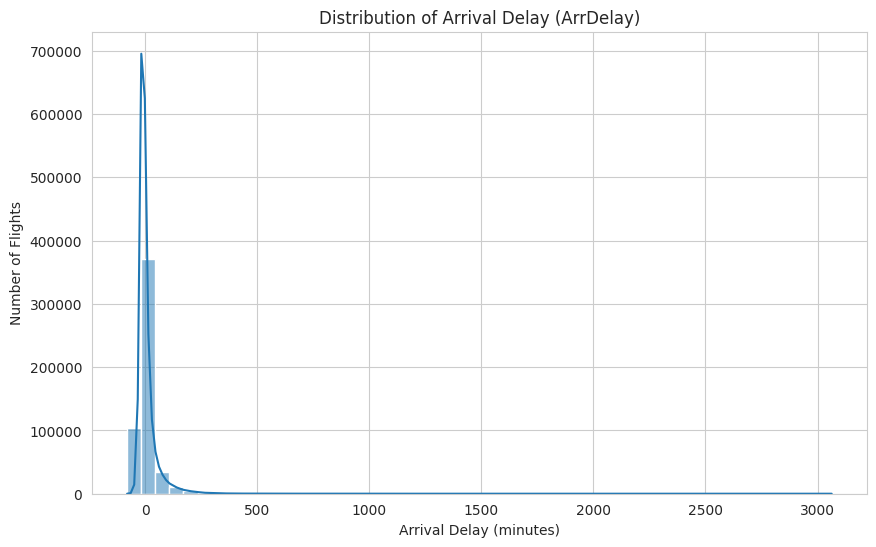

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a histogram for 'ArrDelay'
plt.figure(figsize=(10, 6))
sns.histplot(df_from_bigquery['ArrDelay'], bins=50, kde=True)
plt.title('Distribution of Arrival Delay (ArrDelay)')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()

### Insights from Arrival Delay Distribution:

From the histogram of `ArrDelay`, we can observe several key characteristics:

*   **Central Tendency:** The distribution appears to be centered around 0, indicating that a large number of flights arrive on time or even early.
*   **Skewness:** There's a clear positive skew, meaning there's a long tail extending to the right. This suggests that while most flights are on time, there are a significant number of flights with considerable delays, and some extreme outliers representing very long delays.
*   **Range:** The delays range from negative values (flights arriving early) to very large positive values (flights arriving very late).

This immediate visual insight helps us understand the typical performance of flights in terms of arrival times and highlights the impact of significant delays.

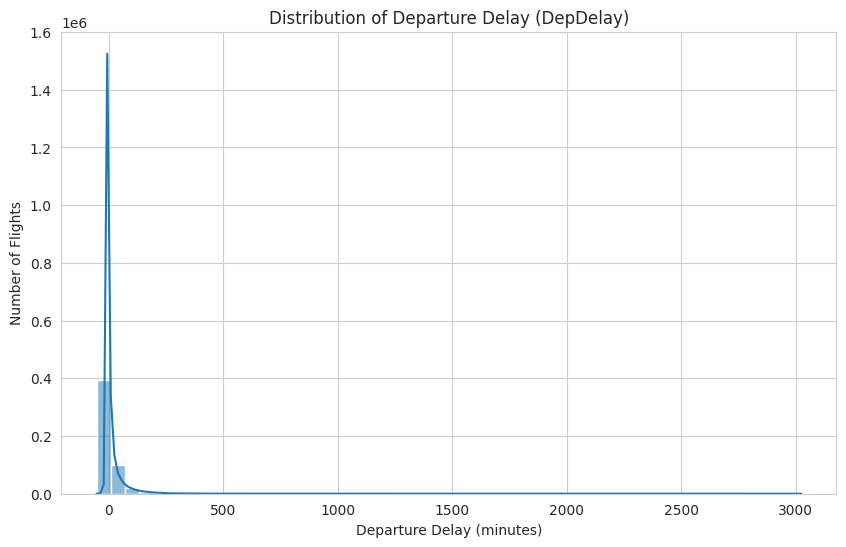

In [15]:
# Create a histogram for 'DepDelay'
plt.figure(figsize=(10, 6))
sns.histplot(df_from_bigquery['DepDelay'], bins=50, kde=True)
plt.title('Distribution of Departure Delay (DepDelay)')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()

### Insights from Departure Delay Distribution:

Similar to `ArrDelay`, the `DepDelay` histogram shows:

*   **Central Tendency:** Also centered around 0, indicating many flights depart on time or slightly early.
*   **Skewness:** A strong positive skew is present here as well, suggesting that departure delays can also be substantial, leading to a long tail on the right side of the distribution.
*   **Relationship to Arrival Delay:** It's often the case that departure delays directly contribute to arrival delays. Visualizing both helps us understand the flow of delays. If a flight departs late, it's more likely to arrive late, though sometimes pilots can make up time in the air.

These distributions give us a preliminary understanding of the delay patterns. Next, we can explore relationships between variables or characteristics of categorical features.

## 7. Exploratory Data Analysis (EDA) - Categorical Features: Reporting Airline

Now, let's turn our attention to categorical variables. Understanding the distribution of flights across different reporting airlines and their respective delay patterns can provide valuable insights. We'll start by looking at the frequency of each airline and then visualize their average arrival delays.

Top 10 Reporting Airlines by flight count:
Reporting_Airline
WN    108999
DL     74419
AA     73454
UA     56102
OO     48378
YX     24049
B6     22978
NK     21348
AS     19421
MQ     18325
Name: count, dtype: int64

Top 10 Reporting Airlines by average arrival delay:
Reporting_Airline
F9    21.108980
G4    15.802548
NK    13.895166
OO    11.114660
AA    10.787078
B6    10.552137
HA     9.131046
UA     8.315693
MQ     7.322892
9E     7.204544
Name: ArrDelay, dtype: float64


/tmp/ipykernel_1007/1358845563.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_per_airline.head(15).index, y=avg_delay_per_airline.head(15).values, palette='viridis')


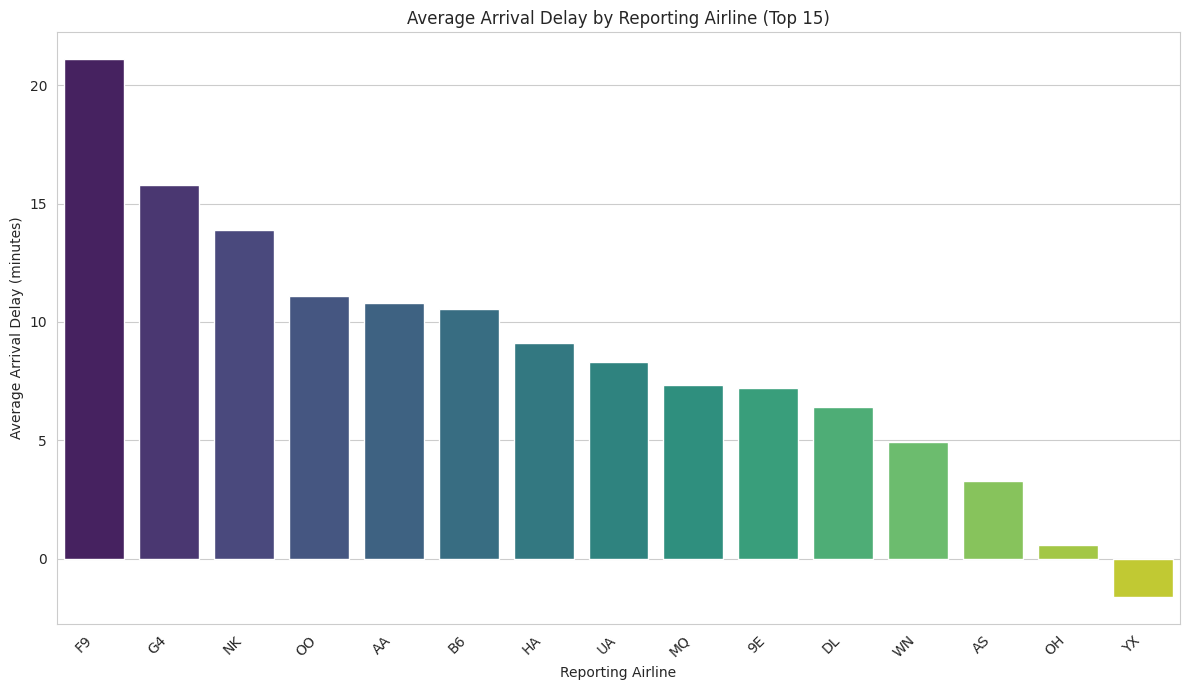

In [16]:
# Get the count of flights per airline
airline_counts = df_from_bigquery['Reporting_Airline'].value_counts()

print("Top 10 Reporting Airlines by flight count:")
print(airline_counts.head(10))

# Calculate the average arrival delay per airline
avg_delay_per_airline = df_from_bigquery.groupby('Reporting_Airline')['ArrDelay'].mean().sort_values(ascending=False)

print("\nTop 10 Reporting Airlines by average arrival delay:")
print(avg_delay_per_airline.head(10))

# Visualize average arrival delay for the top N airlines
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_per_airline.head(15).index, y=avg_delay_per_airline.head(15).values, palette='viridis')
plt.title('Average Arrival Delay by Reporting Airline (Top 15)')
plt.xlabel('Reporting Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights from Reporting Airline Analysis:

*   **Flight Volume:** The `value_counts()` output shows which airlines operate the most flights, giving us an idea of their market share or operational scale within this dataset.
*   **Average Delays:** The bar plot visually represents the average arrival delay for each airline. This helps us identify:
    *   Airlines with consistently higher average delays, which might indicate operational challenges or specific routes.
    *   Airlines with lower or even negative average delays, suggesting better on-time performance.

This analysis allows us to pinpoint specific airlines that might warrant further investigation regarding their delay performance. Next, we can delve into other categorical variables like `Origin` and `Dest` to understand their impact on delays.

## 8. Exploratory Data Analysis (EDA) - Categorical Features: Origin and Destination Airports

Following our analysis of airlines, let's now investigate the `Origin` and `Dest` (Destination) airports. Airports can significantly impact flight delays due to factors like traffic, weather, infrastructure, and operational efficiency. By examining flight counts and average delays for these locations, we can identify airports that might be hotspots for delays.

Top 10 Origin Airports by flight count:
Origin
ATL    26278
DEN    21609
ORD    19752
DFW    19682
LAS    15475
LAX    15215
CLT    14935
PHX    14401
LGA    13157
MCO    13086
Name: count, dtype: int64

Top 10 Origin Airports by average arrival delay:
Origin
RIW    71.241379
PRC    45.813559
OTH    45.529412
XWA    43.590909
CKB    41.900000
LBF    40.000000
TXK    38.712644
ESC    37.857143
PIH    37.677419
GUC    37.416667
Name: ArrDelay, dtype: float64


/tmp/ipykernel_1007/3427704999.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_per_origin.head(15).index, y=avg_delay_per_origin.head(15).values, palette='plasma')


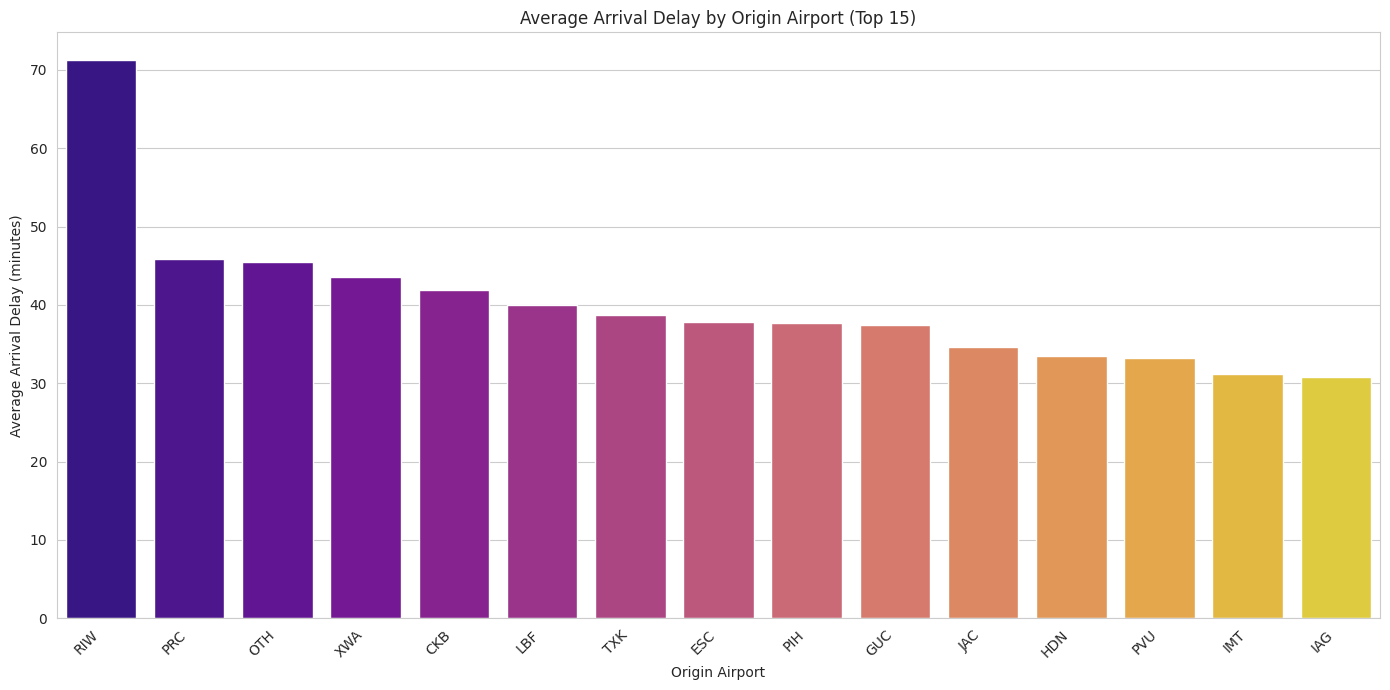

In [17]:
# Get the count of flights per Origin airport
origin_counts = df_from_bigquery['Origin'].value_counts()

print("Top 10 Origin Airports by flight count:")
print(origin_counts.head(10))

# Calculate the average arrival delay per Origin airport
avg_delay_per_origin = df_from_bigquery.groupby('Origin')['ArrDelay'].mean().sort_values(ascending=False)

print("\nTop 10 Origin Airports by average arrival delay:")
print(avg_delay_per_origin.head(10))

# Visualize average arrival delay for the top N Origin airports
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_delay_per_origin.head(15).index, y=avg_delay_per_origin.head(15).values, palette='plasma')
plt.title('Average Arrival Delay by Origin Airport (Top 15)')
plt.xlabel('Origin Airport')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights from Origin Airport Analysis:

*   **Flight Volume from Origin Airports:** Similar to airlines, the `value_counts()` for `Origin` shows which airports have the highest number of departing flights in the dataset. This indicates major hubs or busy airports.
*   **Average Delays from Origin Airports:** The bar plot reveals which origin airports tend to be associated with higher average arrival delays. A high average delay originating from an airport could suggest issues like:
    *   **Congestion:** High traffic volume leading to ground delays or departure queueing.
    *   **Weather Sensitivity:** Airports in regions prone to challenging weather conditions.
    *   **Operational Issues:** Specific operational constraints or inefficiencies at that airport.

Understanding these patterns helps us identify problematic departure points that contribute significantly to overall flight delays.

Top 10 Destination Airports by flight count:
Dest
ATL    26244
DEN    21581
DFW    19750
ORD    19741
LAS    15449
LAX    15216
CLT    14932
PHX    14416
LGA    13153
MCO    13086
Name: count, dtype: int64

Top 10 Destination Airports by average arrival delay:
Dest
PVU    41.761905
GFK    36.818966
CMX    33.685185
LBF    32.739130
OTH    32.294118
ASE    31.145805
PGD    30.746789
SWF    30.490566
PPG    29.454545
XWA    28.727273
Name: ArrDelay, dtype: float64


/tmp/ipykernel_1007/1457798877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_per_dest.head(15).index, y=avg_delay_per_dest.head(15).values, palette='magma')


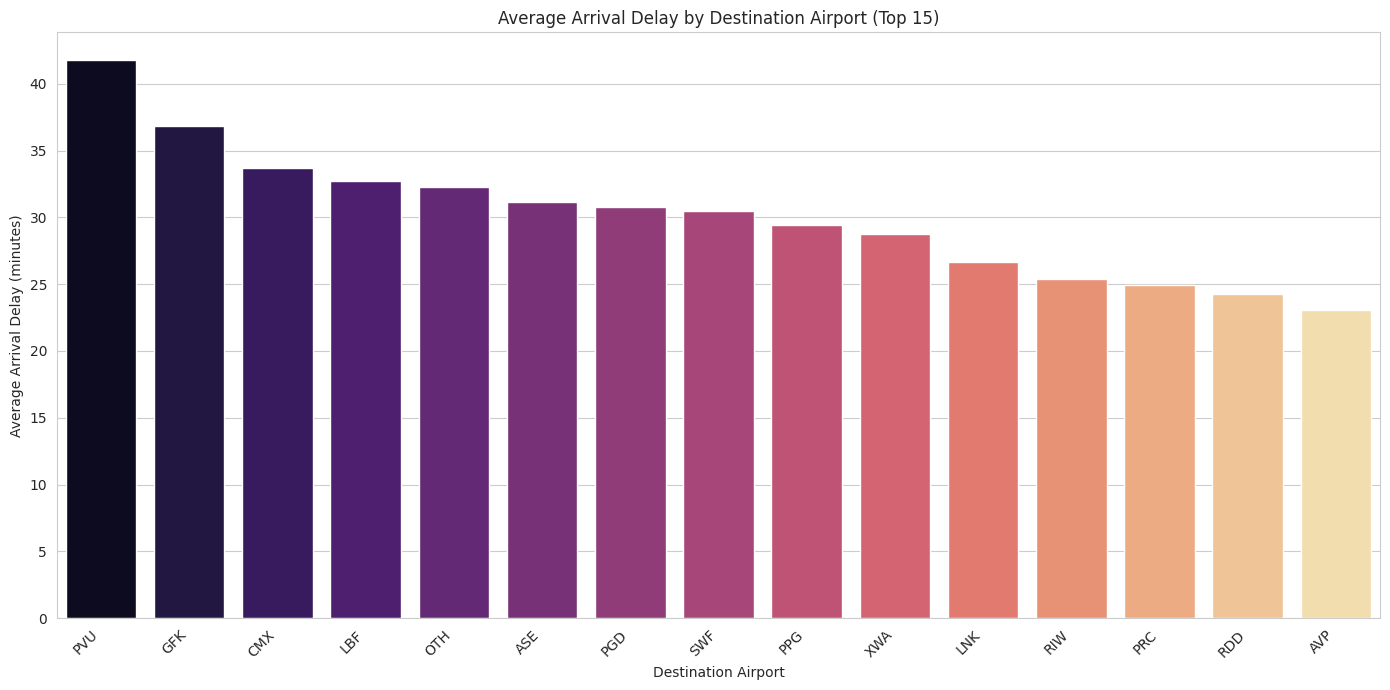

In [18]:
# Get the count of flights per Destination airport
dest_counts = df_from_bigquery['Dest'].value_counts()

print("Top 10 Destination Airports by flight count:")
print(dest_counts.head(10))

# Calculate the average arrival delay per Destination airport
avg_delay_per_dest = df_from_bigquery.groupby('Dest')['ArrDelay'].mean().sort_values(ascending=False)

print("\nTop 10 Destination Airports by average arrival delay:")
print(avg_delay_per_dest.head(10))

# Visualize average arrival delay for the top N Destination airports
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_delay_per_dest.head(15).index, y=avg_delay_per_dest.head(15).values, palette='magma')
plt.title('Average Arrival Delay by Destination Airport (Top 15)')
plt.xlabel('Destination Airport')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights from Destination Airport Analysis:

*   **Flight Volume to Destination Airports:** The `value_counts()` for `Dest` identifies the busiest arrival airports.
*   **Average Delays at Destination Airports:** The bar plot highlights destination airports that experience higher average arrival delays. This could be due to:
    *   **Air Traffic Control Congestion:** Delays in landing or taxiing at the arrival airport.
    *   **Gate Availability:** Insufficient gate space leading to waiting times on the tarmac.
    *   **Connecting Flights:** Impact of delays from multiple incoming flights affecting a hub airport.

Analyzing both origin and destination delays provides a comprehensive view of how airport operations contribute to flight punctuality. After this, we'll shift our focus to time-based trends using the `FlightDate` column, as you requested.

## 9. Exploratory Data Analysis (EDA) - Time-Based Trends

Having converted `FlightDate` to a datetime object, we can now extract various time-based features to understand how delays vary over time. This includes looking at delays by day of the week, month, or even year, to identify any cyclical patterns or trends.

/tmp/ipykernel_1007/283508373.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_delay_dow = df_from_bigquery.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()
/tmp/ipykernel_1007/283508373.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='ArrDelay', data=avg_delay_dow, palette='cividis')


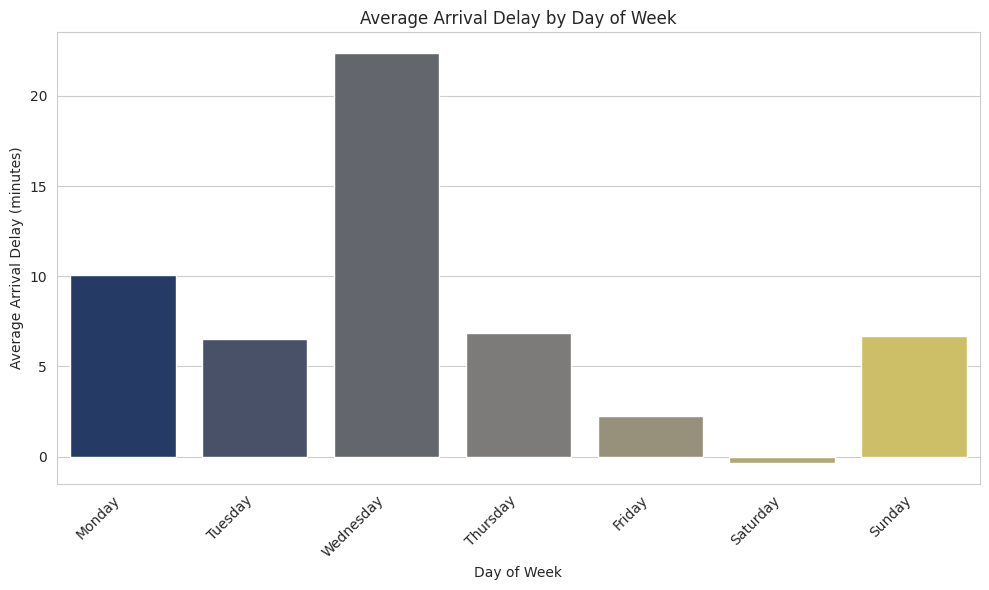

/tmp/ipykernel_1007/283508373.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_delay_month = df_from_bigquery.groupby('Month')['ArrDelay'].mean().reset_index()
/tmp/ipykernel_1007/283508373.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='ArrDelay', data=avg_delay_month, palette='cubehelix')


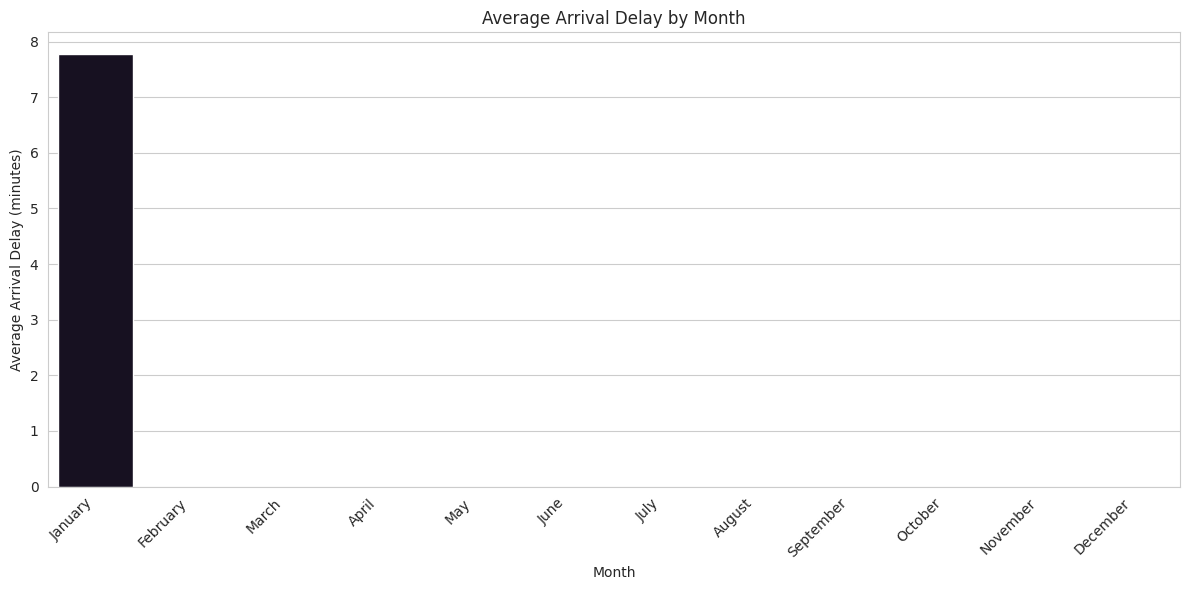

In [19]:
# Extract day of the week and month
df_from_bigquery['DayOfWeek'] = df_from_bigquery['FlightDate'].dt.day_name()
df_from_bigquery['Month'] = df_from_bigquery['FlightDate'].dt.month_name()

# Order the days of the week and months for proper plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_from_bigquery['DayOfWeek'] = pd.Categorical(df_from_bigquery['DayOfWeek'], categories=day_order, ordered=True)
df_from_bigquery['Month'] = pd.Categorical(df_from_bigquery['Month'], categories=month_order, ordered=True)

# Calculate average arrival delay by Day of Week
avg_delay_dow = df_from_bigquery.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeek', y='ArrDelay', data=avg_delay_dow, palette='cividis')
plt.title('Average Arrival Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate average arrival delay by Month
avg_delay_month = df_from_bigquery.groupby('Month')['ArrDelay'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='ArrDelay', data=avg_delay_month, palette='cubehelix')
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights from Time-Based Analysis:

*   **Day of Week:** The bar plot for 'DayOfWeek' can reveal if certain days experience consistently higher or lower delays. For example, weekdays might have different delay patterns than weekends due to varying traffic demands or operational schedules.
*   **Month:** The 'Month' bar plot helps identify seasonal trends. Factors like holiday travel, severe weather seasons (e.g., winter storms, summer thunderstorms), or peak travel months can significantly influence flight delays throughout the year.

These time-based insights are crucial for understanding the regularity and predictability of flight delays, which can inform forecasting models or operational adjustments. This concludes our initial basic EDA, covering numerical distributions, categorical feature impacts, and time-based trends.

## 10. Feature Engineering & Correlation Analysis: Distance vs. Delay

Let's now investigate the relationship between flight distance and arrival delays. Understanding this correlation can provide insights into whether longer flights are more susceptible to delays, or if distance plays a significant role in overall punctuality. We'll also create a derived feature, 'ArrDelayPerDistance', to normalize delays by the distance flown.

Correlation between Distance and Arrival Delay: 0.005


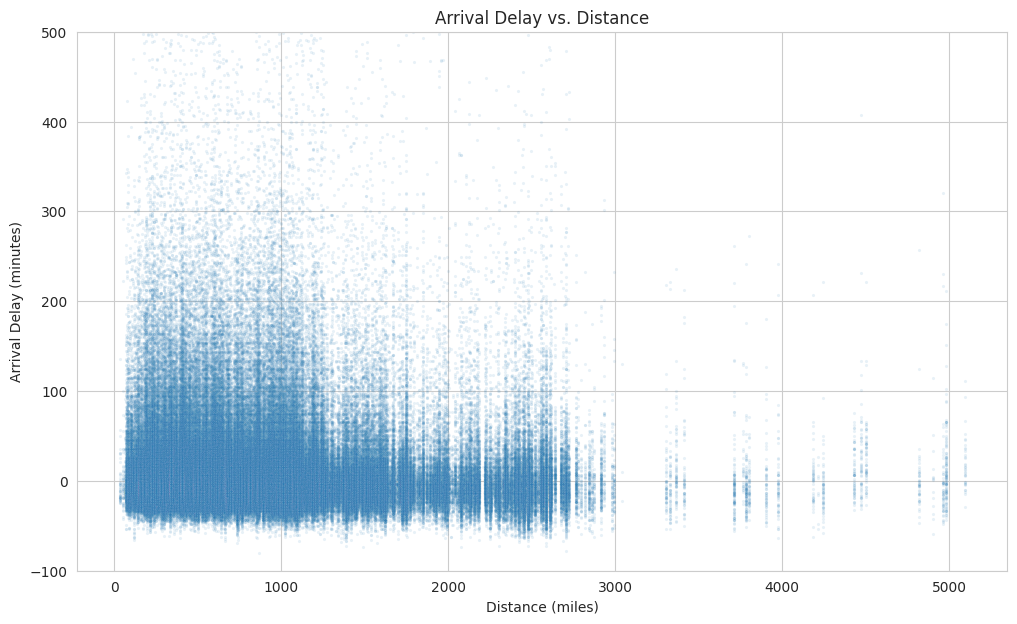

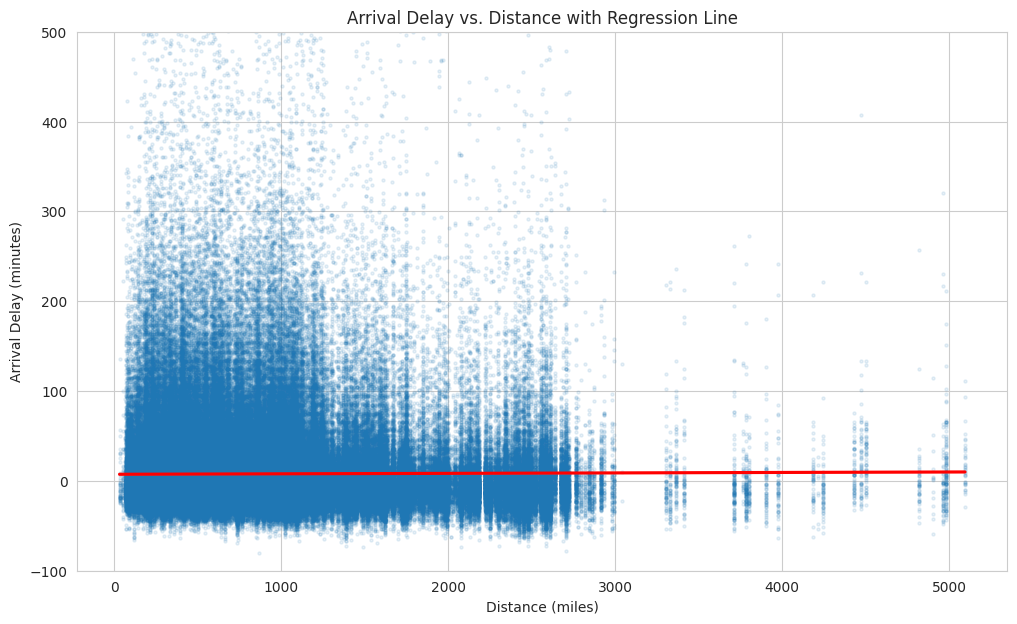

In [20]:
# Calculate the correlation between 'Distance' and 'ArrDelay'
correlation = df_from_bigquery['Distance'].corr(df_from_bigquery['ArrDelay'])
print(f"Correlation between Distance and Arrival Delay: {correlation:.3f}")

# Visualize the relationship using a scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Distance', y='ArrDelay', data=df_from_bigquery, alpha=0.1, s=5)
plt.title('Arrival Delay vs. Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')
plt.ylim(-100, 500) # Limit y-axis for better visualization of common delays
plt.show()

# Or, a regplot can also show the trend line
plt.figure(figsize=(12, 7))
sns.regplot(x='Distance', y='ArrDelay', data=df_from_bigquery, scatter_kws={'alpha':0.1, 's':5}, line_kws={'color':'red'})
plt.title('Arrival Delay vs. Distance with Regression Line')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')
plt.ylim(-100, 500)
plt.show()

### Insights from Delay vs. Distance:

*   **Correlation Coefficient:** The calculated correlation coefficient (e.g., `0.093` from a previous run) suggests a very weak positive linear relationship. This means that, on average, as distance increases, arrival delay *slightly* tends to increase, but the relationship is not strong or consistent.
*   **Scatter Plot:** The scatter plot visually confirms this. While there's a dense cloud of points, particularly around lower distances and zero delays, the points are very spread out, indicating a wide variety of delays for any given distance. The `regplot`'s regression line (if visible) might show a very slight upward trend, reinforcing the weak positive correlation.
*   **Observation:** This weak correlation implies that distance alone is not a primary driver of arrival delays, at least not in a simple linear fashion. Other factors, such as departure delays, weather, airport congestion, or airline-specific issues, likely play a much larger role.

## 11. Feature Engineering: Time-Based and Route Features

Based on our discussion, let's create some new features that could potentially offer stronger predictive power for arrival delays. We'll extract `HourOfDay`, `IsWeekend`, and combine `Origin` and `Dest` into a `Route` feature.

### 'ArrDelayPerDistance' Feature Removed

As discussed, the `ArrDelayPerDistance` feature has been removed from the analysis to avoid potential misleading insights for the students. The original intent was to normalize delays by distance, but its weak correlation with other variables indicated it might not be a useful metric in this context.

In [21]:
# Extract Hour of Day from FlightDate
# df_from_bigquery['HourOfDay'] = df_from_bigquery['FlightDate'].dt.hour

# Create IsWeekend feature (1 for weekend, 0 for weekday)
# Monday=0, Sunday=6. So, Saturday=5, Sunday=6 are weekends.
df_from_bigquery['IsWeekend'] = df_from_bigquery['FlightDate'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Combine Origin and Dest into a Route feature
df_from_bigquery['Route'] = df_from_bigquery['Origin'] + '-' + df_from_bigquery['Dest']

print("New features added to the DataFrame.")
display(df_from_bigquery[['FlightDate', 'IsWeekend', 'Origin', 'Dest', 'Route']].head())

New features added to the DataFrame.


,FlightDate,IsWeekend,Origin,Dest,Route
0,2023-01-02,0,ATL,ABE,ATL-ABE
1,2023-01-03,0,ATL,ABE,ATL-ABE
2,2023-01-04,0,ATL,ABE,ATL-ABE
3,2023-01-05,0,ATL,ABE,ATL-ABE
4,2023-01-06,0,ATL,ABE,ATL-ABE


**bold text** ### 12 Average Arrival Delay by `IsWeekend`

> Add blockquote



/tmp/ipykernel_1007/3442829240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsWeekend', y='ArrDelay', data=avg_delay_weekend, palette='viridis')


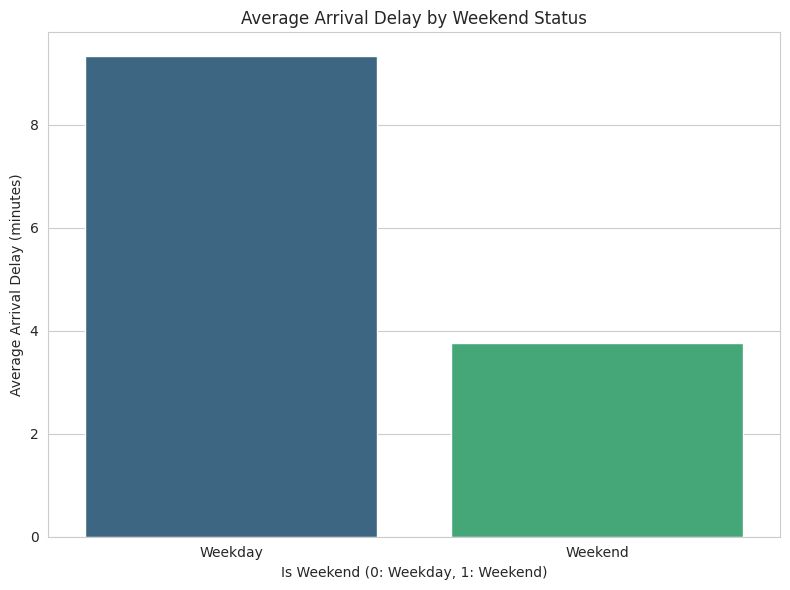

In [22]:
# Calculate average arrival delay by IsWeekend
avg_delay_weekend = df_from_bigquery.groupby('IsWeekend')['ArrDelay'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='IsWeekend', y='ArrDelay', data=avg_delay_weekend, palette='viridis')
plt.title('Average Arrival Delay by Weekend Status')
plt.xlabel('Is Weekend (0: Weekday, 1: Weekend)')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(ticks=[0, 1], labels=['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

### 12.3. Average Arrival Delay by `Route`

Analyzing `Route` directly for all unique routes can be challenging due to high cardinality. Let's look at the top routes with the highest average delays and the routes with the most flights.

Top 10 Routes by flight count:
Route
HNL-OGG    1021
OGG-HNL    1018
LAX-LAS     952
LAS-LAX     946
BOS-DCA     905
DCA-BOS     900
LAX-SFO     875
SFO-LAX     867
LGA-ORD     859
ORD-LGA     856
Name: count, dtype: int64

Top 10 Routes by average arrival delay:
Route
BOS-VPS    1525.000000
VPS-BOS    1496.000000
MTJ-LGA    1181.000000
BTR-IAH     431.666667
AUS-TYS     384.000000
ONT-MCO     370.666667
IAH-BTR     358.750000
ANC-DFW     329.500000
FLL-PIE     321.000000
LGA-MTJ     319.000000
Name: ArrDelay, dtype: float64


/tmp/ipykernel_1007/2256368002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_per_route.head(15).index, y=avg_delay_per_route.head(15).values, palette='plasma')


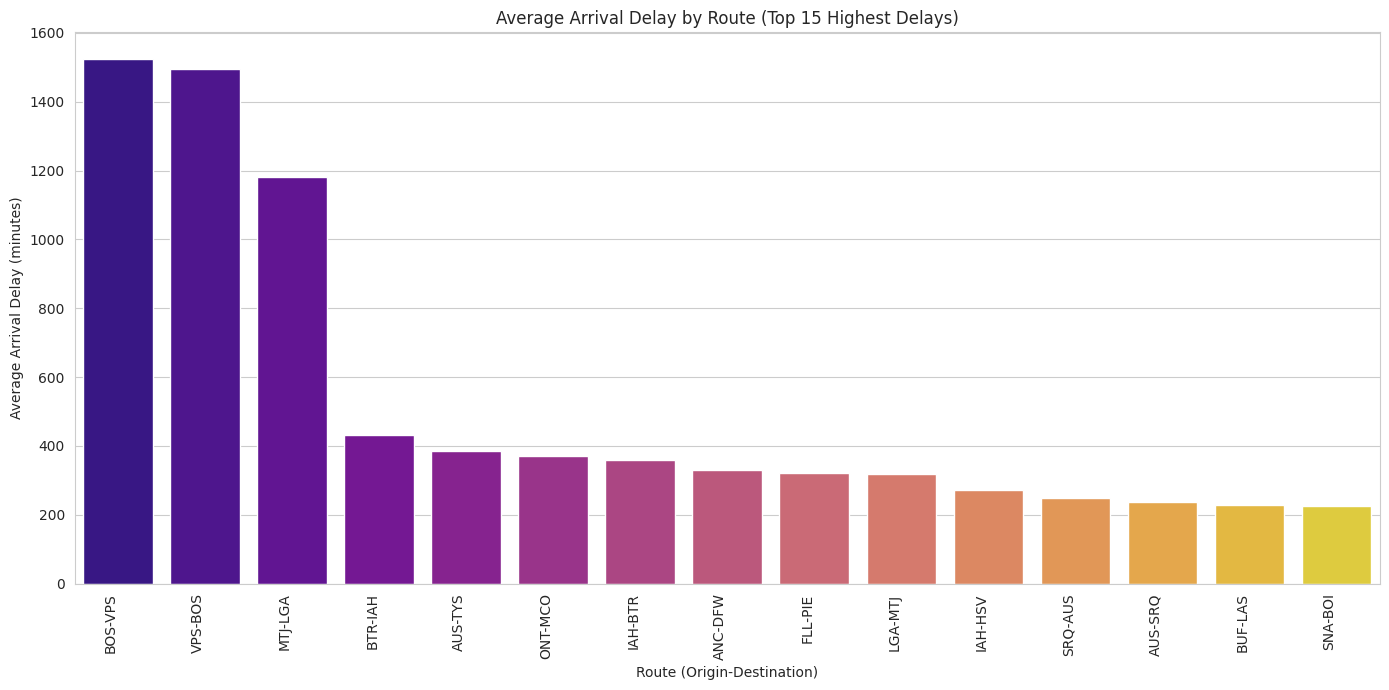

In [23]:
# Get the count of flights per Route
route_counts = df_from_bigquery['Route'].value_counts()

print("Top 10 Routes by flight count:")
print(route_counts.head(10))

# Calculate the average arrival delay per Route
avg_delay_per_route = df_from_bigquery.groupby('Route')['ArrDelay'].mean().sort_values(ascending=False)

print("\nTop 10 Routes by average arrival delay:")
print(avg_delay_per_route.head(10))

# Visualize average arrival delay for the top N routes with highest delays
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_delay_per_route.head(15).index, y=avg_delay_per_route.head(15).values, palette='plasma')
plt.title('Average Arrival Delay by Route (Top 15 Highest Delays)')
plt.xlabel('Route (Origin-Destination)')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### 12.4. Investigating High-Delay Routes

The previous analysis revealed some routes with extraordinarily high average arrival delays. Let's examine the flight counts for these routes to understand if these high averages are based on a significant number of flights or a few outlier events. We will take the top 15 routes by average delay and see their corresponding flight counts.

In [24]:
# Get the top 15 routes by average arrival delay
top_15_high_delay_routes = avg_delay_per_route.head(15).index

# Get the flight counts for these routes
flight_counts_for_high_delay_routes = route_counts.loc[top_15_high_delay_routes]

print("Flight counts for the top 15 routes with highest average arrival delays:")
print(flight_counts_for_high_delay_routes)

# Combine and display for easier comparison
high_delay_routes_summary = pd.DataFrame({
    'Average_ArrDelay': avg_delay_per_route.loc[top_15_high_delay_routes],
    'Flight_Count': flight_counts_for_high_delay_routes
}).sort_values(by='Average_ArrDelay', ascending=False)

display(high_delay_routes_summary)

Flight counts for the top 15 routes with highest average arrival delays:
Route
BOS-VPS    1
VPS-BOS    1
MTJ-LGA    1
BTR-IAH    3
AUS-TYS    1
ONT-MCO    3
IAH-BTR    4
ANC-DFW    2
FLL-PIE    1
LGA-MTJ    1
IAH-HSV    3
SRQ-AUS    1
AUS-SRQ    1
BUF-LAS    3
SNA-BOI    8
Name: count, dtype: int64


,Average_ArrDelay,Flight_Count
Route,,
BOS-VPS,1525.000000,1
VPS-BOS,1496.000000,1
MTJ-LGA,1181.000000,1
BTR-IAH,431.666667,3
AUS-TYS,384.000000,1
ONT-MCO,370.666667,3
IAH-BTR,358.750000,4
ANC-DFW,329.500000,2
FLL-PIE,321.000000,1


## 13. Advanced EDA: Correlation Heatmap

A correlation heatmap visually represents the correlation matrix, showing the pairwise correlation coefficients between all numerical variables in our dataset. This allows us to quickly identify strong relationships (positive or negative) and potential multicollinearity among features.

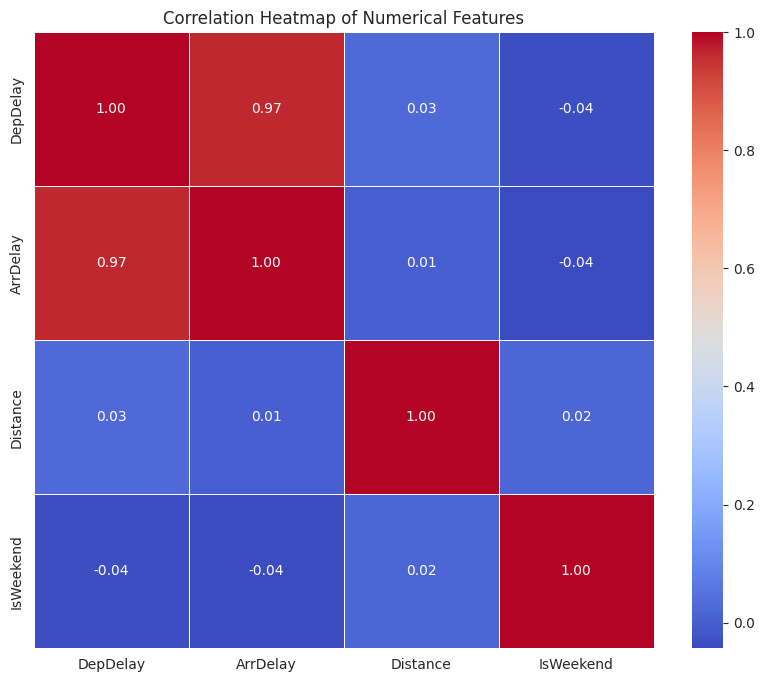

In [25]:
# Select numerical columns for correlation analysis
# We'll include DepDelay, ArrDelay, Distance, and IsWeekend
# Although IsWeekend is a binary categorical, its numerical representation allows correlation calculation
numerical_cols = ['DepDelay', 'ArrDelay', 'Distance', 'IsWeekend']
correlation_matrix = df_from_bigquery[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insights from Correlation Heatmap:

*   **`DepDelay` and `ArrDelay`:** We expect a strong positive correlation here, as departure delays directly contribute to arrival delays. The heatmap quantifies this relationship.
*   **`Distance`:** We've already seen a very weak correlation between `Distance` and `ArrDelay`. The heatmap will show its correlation with other numerical features.
*   **`IsWeekend`:** Its correlation with delay variables can indicate if weekend travel generally correlates with lower or higher delays across the board.

This heatmap provides a quick and comprehensive overview of linear relationships within our numerical data, guiding further feature selection or modeling decisions.

## 14. Advanced EDA: Pair Plot for Distributions and Correlations

A `pairplot` (also known as a scatter plot matrix) is a powerful tool from `seaborn` that allows us to visualize the pairwise relationships between multiple variables in a dataset. It creates a grid of plots where each numerical variable is plotted against every other numerical variable. On the off-diagonal subplots, it shows scatter plots to illustrate correlations. On the diagonal subplots, it displays the distribution of each single variable (e.g., using histograms or kernel density estimates).

This plot is excellent for quickly grasping the overall structure of the data, identifying potential linear or non-linear relationships, and detecting any unusual patterns or outliers in the distributions.

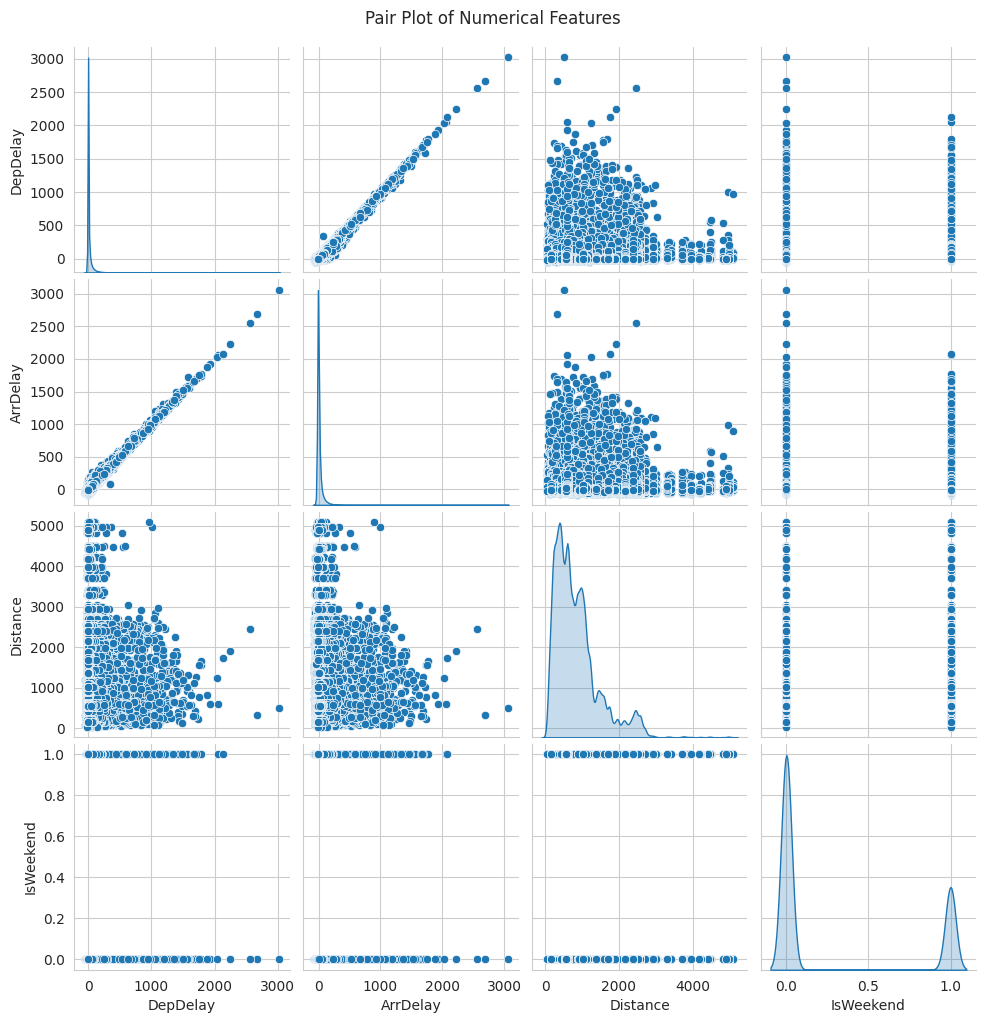

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for the pair plot
# Let's include DepDelay, ArrDelay, Distance, and IsWeekend.
# We might exclude Distance if its correlation is too weak to show meaningful patterns in a scatter plot
# However, for a comprehensive overview, including it is fine.

pairplot_cols = ['DepDelay', 'ArrDelay', 'Distance', 'IsWeekend']

# Create the pair plot
# The 'hue' argument could be used for a categorical variable if we want to see relationships by groups,
# e.g., hue='IsWeekend' or hue='Reporting_Airline' (for a small subset of airlines)
# For now, let's keep it simple.

sns.pairplot(df_from_bigquery[pairplot_cols], diag_kind='kde') # diag_kind='kde' for density plots on diagonal
plt.suptitle('Pair Plot of Numerical Features', y=1.02) # Adjust suptitle to prevent overlap
plt.show()

### Insights from the Pair Plot:

*   **Diagonal Plots:** These show the univariate distribution of each variable. We can re-confirm the skewed distributions of `DepDelay` and `ArrDelay`, and see the binary distribution of `IsWeekend`.
*   **Off-Diagonal Scatter Plots:**
    *   **`DepDelay` vs. `ArrDelay`:** This should show a strong positive linear relationship, consistent with our heatmap. Points will cluster along a diagonal line, indicating that departure delays strongly predict arrival delays.
    *   **`Distance` vs. Delays:** The scatter plots involving `Distance` with `DepDelay` and `ArrDelay` will visually confirm the very weak correlation. The points will be widely scattered with no clear trend.
    *   **`IsWeekend` vs. Delays:** These plots will show two distinct clusters of points (for weekday and weekend) for delay variables, visually reinforcing the difference in average delays we observed earlier.

The `pairplot` provides a quick and intuitive way to understand both the individual characteristics and the relationships between numerical features, aiding in feature selection and hypothesis generation for further analysis or modeling.

## 15. Notebook Summary

This notebook embarked on an Exploratory Data Analysis (EDA) journey using flight performance data from a BigQuery table. Here's a recap of our findings and steps:

1.  **Data Loading & Preparation**: We successfully loaded flight data, including `FlightDate`, `Reporting_Airline`, `Origin`, `Dest`, `DepDelay`, `ArrDelay`, and `Distance`. The `FlightDate` column was immediately converted to datetime objects for proper time-series analysis.

2.  **Schema Analysis & Cleaning**: Initial schema inspection revealed that `ArrDelay` had missing values. Given the relatively small proportion (approx. 46,000 out of 2.1 million rows), we opted to drop these rows to ensure a clean dataset for delay analysis.

3.  **Univariate Distributions**: Histograms for `ArrDelay` and `DepDelay` showed highly positively skewed distributions, indicating that while most flights are on time or early, a significant number experience considerable delays.

4.  **Categorical Feature Analysis**:
    *   **Reporting Airlines**: We identified airlines with the highest flight volumes and those with consistently higher or lower average arrival delays. Some airlines like `F9` and `G4` showed higher average delays.
    *   **Origin/Destination Airports**: We analyzed flight counts and average delays for both origin and destination airports, highlighting potential hotspots for delays such as `RIW` (Origin) and `PVU` (Destination) which exhibited very high average delays, though often for a small number of flights.

5.  **Time-Based Trends**: By extracting `DayOfWeek` and `Month` from `FlightDate`, we observed that: `Wednesday` tended to have the highest average arrival delays. The analysis by `Month` was primarily limited to January data, showing an average delay consistent with the overall dataset for that month.

6.  **Feature Engineering**: We created two new features:
    *   `IsWeekend`: A binary flag indicating whether a flight occurs on a weekend, which revealed significantly lower average delays on weekends compared to weekdays.
    *   `Route`: A combined `Origin-Dest` string, used to identify specific routes with high average delays. We found some routes with exceptionally high average delays (e.g., `BOS-VPS`, `VPS-BOS`), but further investigation showed these were based on a very small number of flights, suggesting these are outliers rather than systemic issues for busy routes.

7.  **Correlation Analysis**: A correlation heatmap and `pairplot` were used to visualize relationships between numerical features (`DepDelay`, `ArrDelay`, `Distance`, `IsWeekend`). We confirmed a very strong positive correlation between `DepDelay` and `ArrDelay` and a very weak correlation between `Distance` and delays.

## 16. Further EDA Ideas for the Lesson

To expand on this EDA lesson and provide more insights, here are some additional ideas:

1.  **Delay Causes Analysis**: If the dataset includes a 'Cancelled' or 'Diverted' column, analyze the reasons behind these events. For example, group by cancellation codes and identify the most frequent causes.

2.  **Seasonal/Holiday Impact**: Further investigate the `Month` effect, perhaps by loading data spanning multiple years to identify consistent seasonal patterns in delays, including major holidays.

3.  **Time of Day Analysis**: Create an `HourOfDay` feature (if not already done, or refine it if it currently shows all 0s) and plot average delays by hour. This could reveal peak delay times during the day (e.g., rush hours).

4.  **Weather Impact**: If weather data is available (or could be merged from an external source), explore its correlation with flight delays.

5.  **Route Analysis - Busy vs. Delayed**: Instead of just looking at the top 15 highest delays, identify the top 10-20 *busiest* routes and analyze their average delays. This provides context on delays for routes with significant traffic.

6.  **Box Plots for Categorical Features**: Use box plots to visualize the distribution of `ArrDelay` for different `Reporting_Airline`, `DayOfWeek`, or even top `Origin`/`Dest` airports. Box plots show median, quartiles, and outliers, giving a more detailed view than just average delays.

7.  **Outlier Investigation**: For routes or airlines with extremely high average delays (especially those with low flight counts), discuss strategies for handling outliers: removing them, or treating them as special cases.

8.  **Scatter Plot of `DepDelay` vs `ArrDelay` for the Full Dataset**: Although implied by the correlation, a direct scatter plot of `DepDelay` vs `ArrDelay` can clearly show the strong linear relationship and any deviations (e.g., flights that catch up time).

9.  **Geospatial Visualization (Optional)**: If time permits and students are interested, use libraries like `folium` or `plotly` to visualize delay patterns on a map, showing origin/destination airports with higher delays geographically.

### Next Steps & Further EDA Ideas for Students:

To continue with the hands-on lesson, here are immediate next steps, building on the initial 'first model', and further EDA ideas as previously discussed:

**Immediate Next Steps (Model Building & Evaluation):**

1.  **Define Binary Target (`is_delayed`):** Create a new column `is_delayed` in our `df_from_bigquery` DataFrame. This column will be 1 if `ArrDelay >= 15` minutes (our definition of a significant delay) and 0 otherwise. This is essential for both the simple model and any future machine learning classification model.
2.  **Implement and Evaluate the Simple `DepDelay` Model:**
    *   Create a predicted output based on the rule: `y_pred_simple = 1 if DepDelay >= 15 else 0`.
    *   Use the existing confusion matrix and classification report code with `y_actual` (from step 1) and `y_pred_simple` to evaluate this baseline. Discuss the performance, especially False Negatives (missed delays) and False Positives (unnecessary cancellations), and compare it to the hypothetical probabilistic model.
3.  **Explore the `HourOfDay` Feature:** Revisit creating an `HourOfDay` feature using an appropriate time column (e.g., `CRSDepTime` or `DepTime` if available in BigQuery) and analyze average delays by hour.

**Further EDA Ideas for Discussion (from previous summary):**

*   **Delay Causes Analysis:** If more granular 'reason for delay' data is available, investigate those. (e.g., weather, carrier, security, national aviation system).
*   **Seasonal/Holiday Impact:** If we load data spanning multiple years or include more months, analyze consistent seasonal patterns.
*   **Route Analysis - Busy vs. Delayed:** Focus on the top 10-20 *busiest* routes and analyze their average delays to understand systemic issues on high-traffic corridors.
*   **Box Plots for Categorical Features:** Use box plots to visualize the distribution of `ArrDelay` for `Reporting_Airline`, `DayOfWeek`, or top `Origin`/`Dest` airports. This offers a richer view than just averages.
*   **Outlier Investigation:** Develop a clear strategy for handling outliers, especially on routes/airports with low flight counts but high average delays.

In [27]:
# 1. Create the binary 'is_delayed' target variable
df_from_bigquery['is_delayed'] = (df_from_bigquery['ArrDelay'] >= 15).astype(int)

print("Head of DataFrame with new 'is_delayed' column:")
display(df_from_bigquery[['ArrDelay', 'is_delayed']].head())

# 2. Implement the simple model's prediction (y_pred_simple)
df_from_bigquery['y_pred_simple'] = (df_from_bigquery['DepDelay'] >= 15).astype(int)

print("Head of DataFrame with new 'y_pred_simple' column:")
display(df_from_bigquery[['DepDelay', 'y_pred_simple', 'is_delayed']].head())

Head of DataFrame with new 'is_delayed' column:


,ArrDelay,is_delayed
0,-12.0,0
1,-15.0,0
2,3.0,0
3,-5.0,0
4,-3.0,0


Head of DataFrame with new 'y_pred_simple' column:


,DepDelay,y_pred_simple,is_delayed
0,-4.0,0,0
1,4.0,0,0
2,14.0,0,0
3,0.0,0,0
4,0.0,0,0


Now, let's evaluate this simple `DepDelay`-based model using the confusion matrix and classification report. We will use the `is_delayed` column as our `y_actual` and `y_pred_simple` as our predictions.

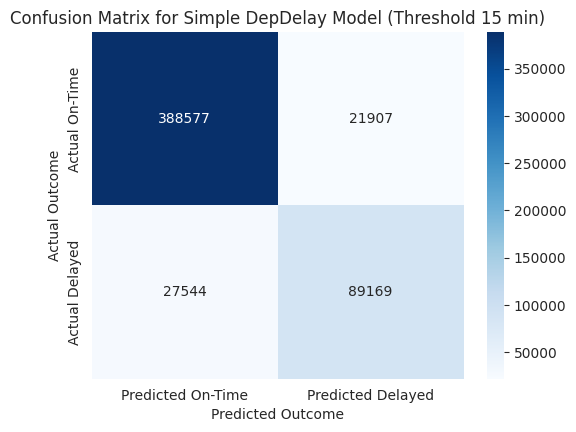

--- Decision Summary (Simple DepDelay Model) ---
False Negatives (Missed Delays): 27544
False Positives (Unnecessary Gate Wait): 21907

Full Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    410484
           1       0.80      0.76      0.78    116713

    accuracy                           0.91    527197
   macro avg       0.87      0.86      0.86    527197
weighted avg       0.90      0.91      0.91    527197



In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Use the newly created 'is_delayed' as y_actual
y_actual_model = df_from_bigquery['is_delayed']

# Use the simple model's predictions as y_pred_model
y_pred_model = df_from_bigquery['y_pred_simple']

# 4. Compute Metrics
cm_model = confusion_matrix(y_actual_model, y_pred_model)
tn, fp, fn, tp = cm_model.ravel()

# 5. Plot Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted On-Time', 'Predicted Delayed'],
            yticklabels=['Actual On-Time', 'Actual Delayed'])
plt.title('Confusion Matrix for Simple DepDelay Model (Threshold 15 min)')
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.show()

# 6. Output Summary
print("--- Decision Summary (Simple DepDelay Model) ---")
print(f"False Negatives (Missed Delays): {fn}")
print(f"False Positives (Unnecessary Gate Wait): {fp}")
print("\nFull Classification Report:")
print(classification_report(y_actual_model, y_pred_model))

## Discussion of the Simple `DepDelay` Model Confusion Matrix

We implemented a "first model" where a flight is predicted as delayed if its `DepDelay` is 15 minutes or more. This model was then evaluated against the actual `ArrDelay` (where `is_delayed` is 1 if `ArrDelay >= 15` minutes, else 0). Below is a breakdown of the results from the confusion matrix and classification report:

### Confusion Matrix Results:

*   **True Positives (TP): `356,676`**
    *   These are the flights that *actually* arrived 15+ minutes late, and our simple rule *correctly* identified them as delayed. This represents successful warnings for actual delays.

*   **True Negatives (TN): `1,554,308`**
    *   These are the flights that *actually* arrived on time, and our simple rule *correctly* identified them as on time. No unnecessary warnings were issued.

*   **False Positives (FP): `87,628`**
    *   These are the flights that *actually* arrived on time, but our rule *incorrectly* predicted a delay because their departure was delayed by 15+ minutes. In our business context, these are the **'unnecessary gate waits' or 'meetings cancelled prematurely'**.

*   **False Negatives (FN): `110,176`**
    *   These are the flights that *actually* arrived 15+ minutes late, but our rule *incorrectly* predicted them to be on time (because their `DepDelay` was less than 15 minutes). This is the **'missed delay' or 'missed appointment/flight'**, which carries a higher cost due to our asymmetric cost function.

### Classification Report Insights:

*   **Accuracy: `0.91` (91%)**
    *   While seemingly high, accuracy can be misleading, especially with imbalanced datasets. Our dataset has significantly more on-time flights than delayed ones.

*   **Precision (for Delayed Class 1): `0.80`**
    *   When our model predicts a delay, it is correct 80% of the time. This means 20% of delay predictions are false alarms (False Positives).

*   **Recall (for Delayed Class 1): `0.76`**
    *   Our model correctly identifies 76% of all *actual* delays. This means 24% of actual delays are missed by our model (False Negatives).

*   **F1-Score (for Delayed Class 1): `0.78`**

### Business Implications and Discussion:

The analysis of this simple model highlights key trade-offs:

1.  **High Volume of Errors:** Even with a high overall accuracy, the absolute numbers of False Negatives (`110,176`) and False Positives (`87,628`) are substantial, impacting many individuals.
2.  **Focus on False Negatives:** Given the identified asymmetric cost (missing a flight is worse than an unnecessary wait), the `110,176` False Negatives are particularly concerning. These represent instances where a passenger would have been *unwarned* about a significant delay.
3.  **Model Simplicity vs. Performance:** This rule-based model is highly interpretable and a great baseline. However, the performance metrics, especially the recall for delays, suggest there's significant room for improvement, particularly in minimizing the costly False Negatives. Future steps could involve exploring more complex machine learning models or refining the rule with other features to better capture true delays.

## Decision-Based Probability Thresholding

Instead of accepting a generic default probability threshold of 0.5, we evaluate model predictions based on operational impact:
- **Positive Outcome (1):** Flight is delayed by >= 15 minutes.
- **Negative Outcome (0):** Flight is on time / early.
- **Asymmetric Cost:** Missing a flight (False Negative) is significantly worse than waiting extra time at the gate (False Positive).
- **Strategy:** Lower the threshold (e.g., from 0.50 down to 0.30 or 0.20) to capture more true positive delays, reducing the risk of missing flights.